In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss, consistency_loss

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: False


/home/johanna/Doktorand/pose_from_cylinders/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=32,
    dropout=0.1,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debugg=False,
    return_two_pairs=True
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

In [6]:
# bug_check(0)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
lambda_cons = 0.5


model.train()
for epoch in range(100):
    total = 0.0
    total_vis = 0.0
    total_radius = 0-0
    total_depth = 0.0
    total_pose = 0.0
    total_t = 0.0
    total_r = 0.0

    for batch in loader:
        # img_a1, vision_a1, img_b1, pose_ab1 = batch
        img_a1, vision_a1, img_b1, pose_ab1, img_a2, vision_a2, img_b2, pose_ab2 = batch

        img_a1 = img_a1.to(device, non_blocking=True)
        img_b1 = img_b1.to(device, non_blocking=True)
        vision_a1 = vision_a1.to(device, non_blocking=True)
        pose_ab1 = pose_ab1.to(device, non_blocking=True)
        img_a2 = img_a2.to(device, non_blocking=True)
        img_b2 = img_b2.to(device, non_blocking=True)
        vision_a2 = vision_a2.to(device, non_blocking=True)
        pose_ab2 = pose_ab2.to(device, non_blocking=True)

        pred_vision1, pred_pose1 = model(img_a1, img_b1)
        pred_vision2, pred_pose2 = model(img_a2, img_b2)

        loss_out1 = supervised_loss(pred_vision1, vision_a1, pred_pose1, pose_ab1,
            lambda_pose=1.0,
            lambda_vis_a=1.0,
            occ_thresh=0.5,
            lambda_occ=10.0,
            lambda_radius=10.0,
            lambda_depth=1.0,
            t_weight=1.0,
            r_weight=1.0,
        )

        loss_out2 = supervised_loss(pred_vision2, vision_a2, pred_pose2, pose_ab2,
            lambda_pose=1.0,
            lambda_vis_a=1.0,
            occ_thresh=0.5,
            lambda_occ=10.0,
            lambda_radius=10.0,
            lambda_depth=1.0,
            t_weight=1.0,
            r_weight=1.0,
        )

        cons_loss, cons_occ, cons_rad, cons_dep = consistency_loss(
            pred_vision1,
            pred_vision2,
            occ_thresh=0.5,
            match_thresh=0.25,
        )

        loss = loss_out1["total"] + loss_out2["total"] + lambda_cons * cons_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()
        total_vis += loss_out1["vision_a"].item()
        total_radius += loss_out1["vision_a_radius"].item()
        total_pose += loss_out1["pose"].item()
        total_depth += loss_out1["vision_a_depth"].item()
        total_t += loss_out1["translation"].item()
        total_r += loss_out1["rotation"].item()

    n = len(loader)

    print(
        f"Epoch {epoch+1}: "
        f"total={total/n:.4f} | "
        f"vision={total_vis/n:.4f} | "
        f"radius={total_radius/n:.4f} | "
        f"depth={total_depth/n:.4f} | "
        f"pose={total_pose/n:.4f} | "
        f"t={total_t/n:.4f} | "
        f"r={total_r/n:.4f}"
    )

Epoch 1: total=28.3461 | vision=13.6638 | radius=0.1520 | depth=5.3004 | pose=0.3438 | t=0.2415 | r=0.1023
Epoch 2: total=27.7031 | vision=13.3771 | radius=0.1395 | depth=5.2631 | pose=0.3062 | t=0.2503 | r=0.0560
Epoch 3: total=27.6807 | vision=13.4120 | radius=0.1312 | depth=5.4357 | pose=0.2999 | t=0.2418 | r=0.0581
Epoch 4: total=27.4422 | vision=13.3538 | radius=0.1355 | depth=5.2846 | pose=0.3036 | t=0.2494 | r=0.0542
Epoch 5: total=26.6302 | vision=13.1476 | radius=0.1319 | depth=5.1535 | pose=0.2964 | t=0.2432 | r=0.0532


In [ ]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

# Samma dataset som i träningen, men utan shuffle för stabil visualisering
infer_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=0.839, ty=0.544, yaw=9.1°
  Pred pose: tx=0.361, ty=0.677, yaw=2.6°
  |err|     : tx=0.478, ty=0.133, sin=0.112, cos=0.012

Sample 1
  GT   pose: tx=-0.927, ty=-0.374, yaw=-19.8°
  Pred pose: tx=-1.262, ty=-0.058, yaw=-19.6°
  |err|     : tx=0.334, ty=0.316, sin=0.004, cos=0.001

Sample 2
  GT   pose: tx=0.895, ty=-0.447, yaw=39.4°
  Pred pose: tx=0.962, ty=-0.108, yaw=43.5°
  |err|     : tx=0.068, ty=0.339, sin=0.054, cos=0.047

Sample 3
  GT   pose: tx=0.651, ty=-0.759, yaw=5.7°
  Pred pose: tx=0.582, ty=-0.812, yaw=1.7°
  |err|     : tx=0.069, ty=0.053, sin=0.069, cos=0.004



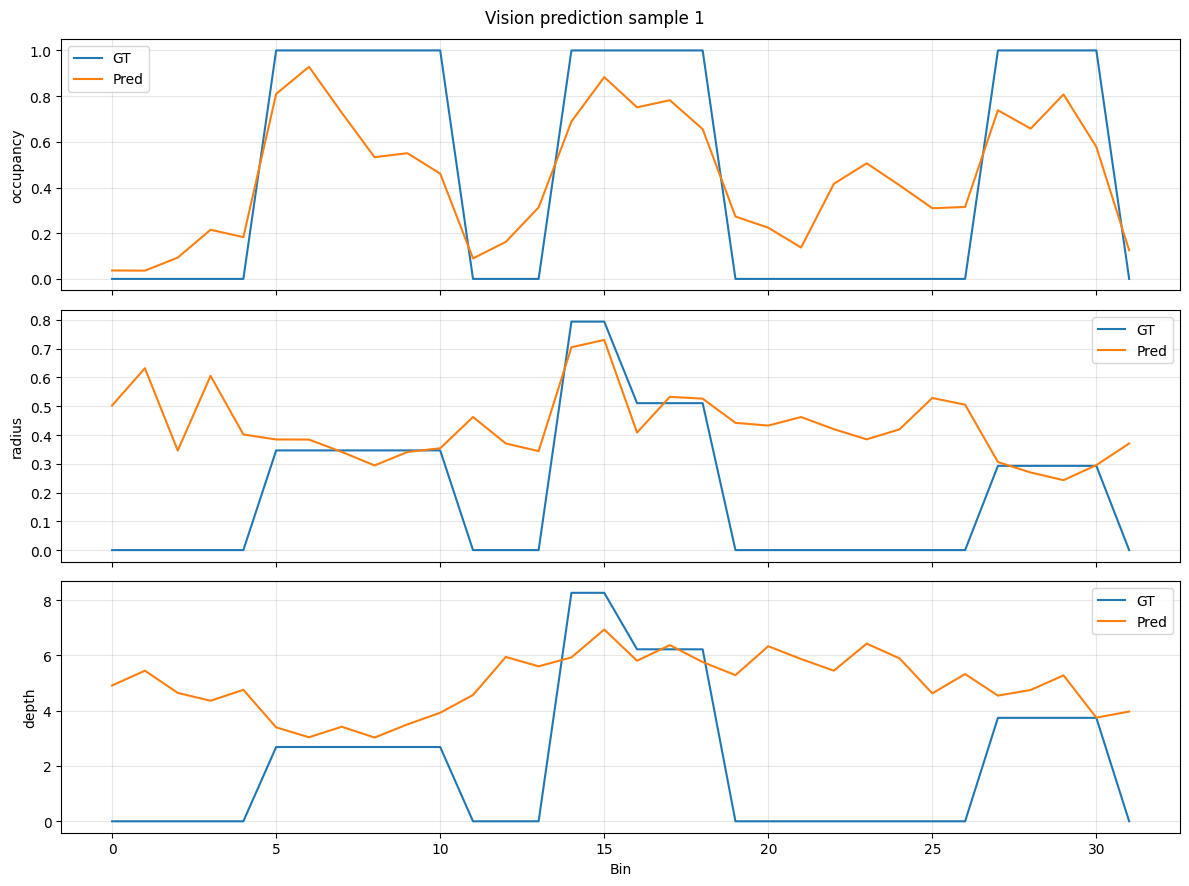

In [ ]:
# Plotta vision-output för första samplet
sample_idx = 1
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT")
    ax.plot(bins, pr, label="Pred")
    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
if False:
    for i in range(n_show):
        show_image_pair(
            img_a[i].detach().cpu(),
            img_b[i].detach().cpu(),
            title=f"Sample {i} | GT pose: {pose_to_text(pose_ab[i].detach().cpu())}"
        )

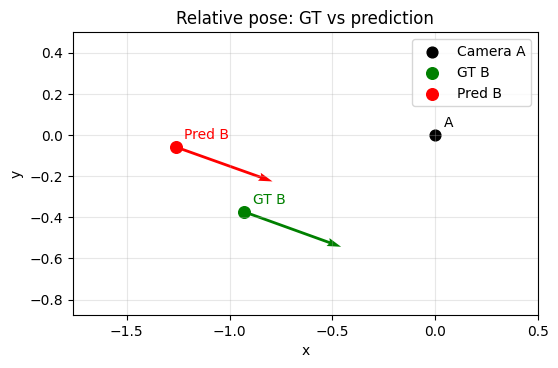

pred_vision shape: torch.Size([4, 32, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([-0.9274, -0.3740, -0.3392,  0.9407])
Pred pose: tensor([-1.2619, -0.0579, -0.3355,  0.9420])


In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())